# Data Analysis

Before beginning the evaluation of AI outputs, especially sentiments, we need to assess the quality of the datasets used by the chatbot. This step ensures that the data is clean, balanced and free from basic DQ issues that could negatively affect the AI's performance.

To perform this task, follow these steps:

- import Required Libraries for data analysis and manipulation
- read the provided datasets into appropriate data structures
- identify Issues in the Datasets: Duplicates, Imbalances, Completeness, Biases (mention type if possible), Relevance and Consistency
found issues should be visualized

It is a good practice to create reusable functions and methods to automate parts of this process. For example:

Functions to check for duplicates and remove them and etc.

By ensuring the datasets are clean and free from biases or inconsistencies, we can improve the reliability and accuracy of the AI's sentiment analysis and summary generation.

In [22]:
from data_analyzer import *
from data_cleanser import *
import data_analyzer as data_analyzer


# initiate .csv file for writing testing tesults into a file
results_filename = "dq_issues.csv"
data_analyzer.name_of_the_file = results_filename

In [23]:
# movies.csv file analysis

file_name = "movies.csv"
movies_df = pd.read_csv(file_name)

# Industry Standartd:
# - 'movie_id' - numeric, non repeatable number, not null
# - 'title' - text without not recognized characters, not null
# - 'description' - text without not recognized characters, not null, minimum length two words
# - 'release_date' - date in a format 'YYYY-MM-DD', no future dates, no dates older than October 14, 1888, not null
# - 'language_sound' - two letter ISO language code, not null
# - 'Original_Language' - two letter ISO language code, not null
# - 'MPA_film_rating' - one of 'G', 'PG', 'PG-13', 'R', 'NC-17'

# 1. return duplicated rows from dataset and write amount into a file
check_name = "Duplicates"
get_duplicates(movies_df, check_name, file_name)
get_business_duplicates(movies_df, ['movie_id', 'title', 'description', 'release_date'], check_name, file_name)
get_business_duplicates(movies_df, ['title', 'description', 'release_date'], check_name, file_name)
get_business_duplicates(movies_df, ['movie_id'], check_name, file_name)

# 2. return imbalances and write into a file
check_name = "Imbalances"
check_uneven_distribution(movies_df, 'language_sound', check_name, file_name)
check_uneven_distribution(movies_df, 'Original_Language', check_name, file_name)
check_uneven_distribution(movies_df, 'MPA_film_rating', check_name, file_name)


# 3. return completeness (0.0 -> means no missing values present) and write amount into a file
check_name = "Completeness"
get_completeness(movies_df, check_name, file_name)

# 4. bias
check_name = "Bias"
# no possible biases to check for 'movies.csv' file itself

# 5. return relevance
check_name = "Relevance"
check_is_numeric(movies_df, check_name, file_name)
check_is_float(movies_df, check_name, file_name)
check_non_ascii_char(movies_df, check_name, file_name)
check_description_length(movies_df, check_name, file_name)
check_date_format(movies_df, 'release_date', check_name, file_name)
check_is_valid_isocode(movies_df, ['language_sound', 'Original_Language'], check_name, file_name)
check_is_one_of_acceptable(movies_df, 'MPA_film_rating', ['G', 'PG', 'PG-13', 'R', 'NC-17'], check_name, file_name)
print("")


In [24]:
# users.csv analysis

file_name = "users.csv"
users_df = pd.read_csv(file_name)

city_country_df = pd.read_csv("world-cities.csv")
city_country_upd_df = city_country_df.rename(columns={'name': 'city_name', 'country': 'country_name'}).drop(columns=['subcountry', 'geonameid'])

# Industry Standards:
# - 'user_id' - numeric, non repeatable number, not null
# - 'first_name' - text without not recognized characters, not null
# - 'last_name' - text without not recognized characters, not null
# - 'date_of_birth' - date in a format 'YYYY-MM-DD', no future dates, not null
# - 'email' - text in a correct email format, not null
# - 'city' - text without not recognized characters, not null
# - 'country' - text without not recognized characters, not null
# - 'language' - text without not recognized characters, ISO language name, not null


# 1. return duplicated rows from dataset
check_name = "Duplicates"
get_duplicates(users_df, check_name, file_name)
get_business_duplicates(users_df, ['first_name', 'last_name', 'date_of_birth'], check_name, file_name)

# 2. return imbalances
check_name = "Imbalances"
check_uneven_distribution(users_df, 'country', check_name, file_name)
check_uneven_distribution(users_df, 'is_active', check_name, file_name)

# 3. return completeness (0.0 -> means no missing values present)
check_name = "Completeness"
get_completeness(users_df, check_name, file_name)

# 4. return biases
check_name = "Bias"
# check_bias_uneven_distribution(users_df, 'country', check_name, file_name, threshold=10)


# 5. return relevance
check_name = "Relevance"
check_is_numeric(users_df, check_name, file_name)
check_is_float(users_df, check_name, file_name)
check_non_ascii_char(users_df, check_name, file_name)
check_date_format(users_df, 'date_of_birth', check_name, file_name)
check_no_future_dates(users_df, 'date_of_birth', check_name, file_name)
check_email_format(users_df, 'email', check_name, file_name)
check_valid_country_name(users_df, 'country', check_name, file_name)
check_phone_by_country(users_df, 'contact_number', 'country', check_name, file_name)
check_city_by_country(users_df, city_country_upd_df, 'city', 'country', check_name, file_name)
check_language_by_country(users_df, 'language', 'country', check_name, file_name)
print("")


In [25]:
# users_reviews.csv analysis

file_name = "users_reviews.csv"
users_reviews_df = pd.read_csv(file_name)

# Industry Standards:
# - 'review_id' - numeric, non repeatable number, not null
# - 'user_id' - numeric, non repeatable number, not null
# - 'movie_id' - numeric, non repeatable number, not null
# - 'review_text' - text without not recognized characters, not null
# - 'rating' - float, maximum values is 5, not null
# - 'review_date' - date in a format 'YYYY-MM-DD', no future dates, not null


# 1. return duplicated rows from dataset
check_name = "Duplicates"
get_duplicates(users_reviews_df, check_name, file_name)
get_business_duplicates(users_reviews_df, ['review_id', 'user_id', 'movie_id', 'review_text', 'rating'], check_name, file_name)

# 2. return imbalances
check_name = "Imbalances"

# - check imbalances by 'rating' 
rating_groups = [
    {"name": "0 - Zero", "start": 0, "end": 0.1},
    {"name": "1 - Very bad", "start": 0.1, "end": 1},
    {"name": "2 - Bad", "start": 1, "end": 2},
    {"name": "3 - An Average", "start": 2, "end": 3},
    {"name": "4 - Good", "start": 3, "end": 4},
    {"name": "4-5 - Very Good", "start": 4, "end": 5},
    {"name": "5 - Exellent", "start": 4.9, "end": 5.1}
]
users_reviews_with_group_df = categorize_by_rating_groups(users_reviews_df, 'rating', rating_groups, 'rate')
check_uneven_distribution(users_reviews_with_group_df, 'rate', check_name, file_name)

# - check imbalances by 'date_of_birth' -> age generations 
age_groups = [
    {"name": "Gen Alpha", "start": 2013, "end": 2025},
    {"name": "Gen Z", "start": 1997, "end": 2012},
    {"name": "Millennials", "start": 1981, "end": 1996},
    {"name": "Generation X", "start": 1965, "end": 1980},
    {"name": "Baby Boomers", "start": 1946, "end": 1964},
    {"name": "Silent Generation", "start": 1925, "end": 1945},
    {"name": "Greatest Generation", "start": 1901, "end": 1924}
]
users_info_df = users_df[['user_id', 'first_name', 'date_of_birth', 'country']]
users_reviews_extended_df = pd.merge(users_reviews_df, users_info_df, on=['user_id'], how="left")
users_reviews_extended_with_group_df = categorize_by_generation(users_reviews_extended_df, 'date_of_birth', age_groups, output_col='generation')
check_uneven_distribution(users_reviews_extended_with_group_df, 'generation', check_name, file_name)

# - check imbalances by regions groups
users_reviews_extended_with_continent_df = categorize_by_continent(users_reviews_extended_df, 'country', output_col='continent')
check_uneven_distribution(users_reviews_extended_with_continent_df, 'continent', check_name, file_name)
print("")

# 3. return completeness (0.0 -> means no missing values present)
check_name = "Completeness"
get_completeness(users_reviews_df, check_name, file_name)

# 4. return biases on joined dataset
check_name = "Bias"
# review_date is older than the moview 'release_date'
movies_info_df = movies_df[['movie_id', 'title', 'release_date']].fillna("Empty Title")
user_reviews_movies_df = pd.merge(users_reviews_df, movies_info_df, on=['movie_id'], how="left")
compare_dates_bias(user_reviews_movies_df, 'review_date', 'release_date', check_name, file_name)

# 5. return relevance
check_name = "Relevance"
check_is_numeric(users_reviews_df, check_name, file_name)
check_is_float(users_reviews_df, check_name, file_name)
check_non_ascii_char(users_reviews_df, check_name, file_name)
check_date_format(users_reviews_df, 'review_date', check_name, file_name)
check_no_future_dates(users_reviews_df, 'review_date', check_name, file_name)

# 6. return consistency on joined dataset
check_name = "Consistency"
check_consistency(users_reviews_df, users_info_df, 'user_id', 'first_name', check_name, file_name)
check_consistency(users_reviews_df, movies_info_df, 'movie_id', 'title', check_name, file_name)



# Possible changes in the dataset:
1) Duplicates (movies.csv): Remove duplicates (full and partial)
2) Imbalances (movies.csv): 
- 'language_sound' = 'it' for 49% of data
- 'Original_Language' = 'en' for 77% of data
- 'MPA_film_rating' = 'G' for 70% of data

Imbalances (users.csv):
- 'is_active' = 0 for 74% of data - needs to generate syntetic data for active users

Imbalances (users_reviews.csv):
- needs to generate syntetic data for 'Millennials' [['Gen Z', 49.29], ['Generation X', 39.68], ['Millennials', 11.02]]

For imbalances issues fix is: minority classes needs to be increased or majority class needs to be decreased. 

3) Completeness (movies.csv):
- delete 9 rows with an empty 'title' (they have also empty 'Original_Language')
- fill 508 rows with an empty 'description' with the same values as in the 'title' with some prefix e.g. 'copied'
4) Bias (users_reviews.csv):
- needs to update 'review_date' based on movie 'release_date' ?
5) Relevance (movies.csv):
- 'release_date' - change format to 'YYYY-MM-DD'
- 'language_sound' = 'cn' replace to 'zh' ('zh' is a correct language code China, not 'cn')
- 'Original_Language' in ['https://image.tmdb.org/t/p/original/6iXYe7AkQ1QIfMFuvXsSCT2zF7s.jpg', 'cn'] replace to 'zh' ('zh' is a correct language code China, not 'cn'),
For the URL value replace to the same in 'language_sound' column

Relevance (users.csv):
- 'phone_number' - lots of incorrect numbers according to the countries -> delete redundant characters ['()', '.', '-']
- 'language' = 'Mandarin' replace with 'Mandarin Chinese'






# Data Cleaning

Propose appropriate changes to address these issues (the goal is to enhance the quality of the datasets, which will help the AI summarization bot produce more accurate and reliable summaries

**Example**:

Duplicates:  
Redundant entries in the data can lead to misleading results during both the analysis and model training. Specifically, if the same review appears multiple times, it can skew sentiment analysis: If a review is repeated multiple times, it could unfairly increase the weight of certain sentiments (positive, neutral, or negative) leading to an unbalanced summary of the movie.
Impact model training: If duplicates are included during training, the model may overfit to these repeated reviews, resulting in biased predictions and inaccurate sentiment understanding.


Proposed change: identify and remove redundant entries from the dataset. To do so we can use pandas

In [26]:
# movies.csv CLEANSING
# 1. Delete duplicated rows
movies_clean_df = remove_duplicates(movies_df, ['movie_id', 'title', 'description', 'release_date'])
movies_clean_df = remove_duplicates(movies_clean_df, ['title', 'description', 'release_date'])
movies_clean_df = remove_duplicates(movies_clean_df, ['movie_id'])

# 2. Delete rows where 'title' and 'description' are empty
movies_clean_df = remove_na_rows_by_columns(movies_clean_df, ['title', 'description'])

# 3. Replace an empty 'description' with the 'title'
movies_clean_df = replace_na_by_column(movies_clean_df, 'title', 'description')
movies_clean_df = replace_na_by_column(movies_clean_df, 'language_sound', 'Original_Language')

# 4. Convert date to 'YYYY-MM-DD' format and delete rows which has incorrect dates (not convertable)
movies_clean_df = convert_date_format(movies_clean_df, 'release_date')

# 5. replace 'cn' tp 'zh' in 'language_sound', 'Original_Language'
movies_clean_df = replace_column_value(movies_clean_df, 'language_sound', 'cn', 'zh')
movies_clean_df = replace_column_value(movies_clean_df, 'Original_Language', 'cn', 'zh')

# users.csv CLEANSING
# 1. Replase 'Mandarin' with 'Mandarin Chinese'
users_clean_df = replace_column_value(users_df, 'language', 'Mandarin', 'Mandarin Chinese')

# users_reviews.csv CLEANSING
# delete user reviews which were on duplicated movies
movie_ids = movies_clean_df['movie_id'].drop_duplicates().to_list()
users_reviews_clean_df = users_reviews_df[users_reviews_df['movie_id'].isin(movie_ids)]

# Convert date to 'YYYY-MM-DD' format and delete rows which has incorrect dates (not convertable)
users_reviews_clean_df = convert_date_format(users_reviews_clean_df, 'review_date')

# replace 'review_date' for 'release_date' for BIAS fixing
movies_info_df = movies_clean_df[['movie_id', 'title', 'release_date']]
users_reviews_clean_df = pd.merge(users_reviews_clean_df, movies_info_df, on=['movie_id'], how="left")
users_reviews_clean_df['review_date'] = np.where(users_reviews_clean_df['review_date'] < users_reviews_clean_df['release_date'], 
                                                 users_reviews_clean_df['release_date'],
                                                 users_reviews_clean_df['review_date'])
users_reviews_clean_df = users_reviews_clean_df.drop(columns=['title', 'release_date', 'rate'])

# Imbalances fixing
- 'language_sound' and 'Original_Language' with 'MPA_film_rating' one of ['R', 'PG-13', 'PG', 'NC-17'] (movie_id starts with 9838) (movies.csv)
- 'is_active' = 1 with 'date_of_birth' between 1981 and 1996 'Millenials' (user_id starts with 5001) (users.csv)
- adding reviews for the generated movies (review_id starts with 15001) (user_reviews.csv)

In [27]:
# Balancing data in movies_clean_df

language_sound = ['en', 'es']
original_language = ['fr', 'es']
mpa_film_rating = ['R', 'PG']

movies_clean_balanced_df, synthetic_movie_ids = generate_synthetic_movies_data(movies_clean_df, language_sound, original_language, 
                                                                               mpa_film_rating, "1950-01-01", "2026-03-20", n_rows=5000)

In [28]:
# Balancing data in users_clean_df
users_clean_balanced_df, synthetic_user_ids = generate_synthetic_users_data(users_clean_df, n_rows=2000)

In [29]:
# Balancing data in users_reviews_clean_df
users_reviews_cb_df = generate_synthetic_reviews_data(users_reviews_clean_df, synthetic_user_ids, synthetic_movie_ids)

# replace an empty 'review_date' with movie 'release_date' + couple of days after release
movies_cb_info_df = movies_clean_balanced_df[['movie_id', 'title', 'release_date']]
users_reviews_clean_balanced_df = pd.merge(users_reviews_cb_df, movies_cb_info_df, on=['movie_id'], how="left")
users_reviews_clean_balanced_df['review_date'] = np.where(users_reviews_clean_balanced_df['review_date'] == "", 
                                                 (pd.to_datetime(users_reviews_clean_balanced_df['release_date']) + 
                                                  pd.Timedelta(days=2)).dt.strftime('%Y-%m-%d'),
                                                 users_reviews_clean_balanced_df['review_date'])
users_reviews_clean_balanced_df = users_reviews_clean_balanced_df.drop(columns=['title', 'release_date'])

In [30]:
results_filename = "dq_issues_after_fixes.csv"
data_analyzer.name_of_the_file = results_filename

In [31]:
# movies_clean_df file analysis

# 1. return duplicated rows from dataset and write amount into a file
file_name = 'movies_clean_balanced_df'
check_name = "Duplicates"
get_duplicates(movies_clean_balanced_df, check_name, file_name)
get_business_duplicates(movies_clean_balanced_df, ['movie_id', 'title', 'description', 'release_date'], check_name, file_name)
get_business_duplicates(movies_clean_balanced_df, ['title', 'description', 'release_date'], check_name, file_name)
get_business_duplicates(movies_clean_balanced_df, ['movie_id'], check_name, file_name)

# 2. return imbalances and write into a file
check_name = "Imbalances"
check_uneven_distribution(movies_clean_balanced_df, 'language_sound', check_name, file_name)
check_uneven_distribution(movies_clean_balanced_df, 'Original_Language', check_name, file_name)
check_uneven_distribution(movies_clean_balanced_df, 'MPA_film_rating', check_name, file_name)

# 3. return completeness (0.0 -> means no missing values present) and write amount into a file
check_name = "Completeness"
get_completeness(movies_clean_balanced_df, check_name, file_name)

# 5. return relevance
check_name = "Relevance"
check_is_numeric(movies_clean_balanced_df, check_name, file_name)
check_is_float(movies_clean_balanced_df, check_name, file_name)
check_non_ascii_char(movies_clean_balanced_df, check_name, file_name)
check_description_length(movies_clean_balanced_df, check_name, file_name)
check_date_format(movies_clean_balanced_df, 'release_date', check_name, file_name)
check_is_valid_isocode(movies_clean_balanced_df, ['language_sound', 'Original_Language'], check_name, file_name)
check_is_one_of_acceptable(movies_clean_balanced_df, 'MPA_film_rating', ['G', 'PG', 'PG-13', 'R', 'NC-17'], check_name, file_name)
print("")


In [32]:
# users_clean_df file analysis

# 1. return duplicated rows from dataset
file_name = 'users_clean_balanced_df'
check_name = "Duplicates"
get_duplicates(users_clean_balanced_df, check_name, file_name)
get_business_duplicates(users_clean_balanced_df, ['first_name', 'last_name', 'date_of_birth'], check_name, file_name)

# 2. return imbalances
check_name = "Imbalances"
check_uneven_distribution(users_clean_balanced_df, 'country', check_name, file_name)
check_uneven_distribution(users_clean_balanced_df, 'is_active', check_name, file_name)

# 3. return completeness (0.0 -> means no missing values present)
check_name = "Completeness"
get_completeness(users_clean_balanced_df, check_name, file_name)

# 5. return relevance
check_name = "Relevance"
check_is_numeric(users_clean_balanced_df, check_name, file_name)
check_is_float(users_clean_balanced_df, check_name, file_name)
check_date_format(users_clean_balanced_df, 'date_of_birth', check_name, file_name)
check_no_future_dates(users_clean_balanced_df, 'date_of_birth', check_name, file_name)
check_email_format(users_clean_balanced_df, 'email', check_name, file_name)
print("")


In [33]:
# users_reviews_clean_df analysis

# 1. return duplicated rows from dataset
file_name = 'users_reviews_clean_balanced_df'
check_name = "Duplicates"
get_duplicates(users_reviews_clean_balanced_df, check_name, file_name)
get_business_duplicates(users_reviews_clean_balanced_df, ['review_id', 'user_id', 'movie_id', 'review_text', 'rating'], check_name, file_name)

# 2. return imbalances
check_name = "Imbalances"
users_reviews_with_group_df = categorize_by_rating_groups(users_reviews_clean_balanced_df, 'rating', rating_groups, 'rate')
check_uneven_distribution(users_reviews_with_group_df, 'rate', check_name, file_name)

users_info_df = users_clean_balanced_df[['user_id', 'first_name', 'date_of_birth', 'country']]
users_reviews_extended_df = pd.merge(users_reviews_clean_balanced_df, users_info_df, on=['user_id'], how="left")
users_reviews_extended_with_group_cb_df = categorize_by_generation(users_reviews_extended_df, 'date_of_birth', age_groups, output_col='generation')
check_uneven_distribution(users_reviews_extended_with_group_cb_df, 'generation', check_name, file_name)

# - check imbalances by regions groups
users_reviews_extended_with_continent_df = categorize_by_continent(users_reviews_extended_df, 'country', output_col='continent')
check_uneven_distribution(users_reviews_extended_with_continent_df, 'continent', check_name, file_name)
print("")

# 3. return completeness (0.0 -> means no missing values present)
check_name = "Completeness"
get_completeness(users_reviews_clean_balanced_df, check_name, file_name)

# 4. return biases on joined dataset
check_name = "Bias"
# review_date is older than the moview 'release_date'
movies_info_df = movies_clean_balanced_df[['movie_id', 'title', 'release_date']]
user_reviews_movies_df = pd.merge(users_reviews_clean_balanced_df, movies_info_df, on=['movie_id'], how="left")
compare_dates_bias(user_reviews_movies_df, 'review_date', 'release_date', check_name, file_name)

# 5. return relevance
check_name = "Relevance"
check_is_numeric(users_reviews_clean_balanced_df, check_name, file_name)
check_is_float(users_reviews_clean_balanced_df, check_name, file_name)
check_non_ascii_char(users_reviews_clean_balanced_df, check_name, file_name)
check_date_format(users_reviews_clean_balanced_df, 'review_date', check_name, file_name)
check_no_future_dates(users_reviews_clean_balanced_df, 'review_date', check_name, file_name)

# 6. return consistency on joined dataset
check_name = "Consistency"
check_consistency(users_reviews_clean_balanced_df, users_clean_balanced_df, 'user_id', 'first_name', check_name, file_name)
check_consistency(users_reviews_clean_balanced_df, movies_clean_balanced_df, 'movie_id', 'title', check_name, file_name)



# Fixed Imbalance Visualization 

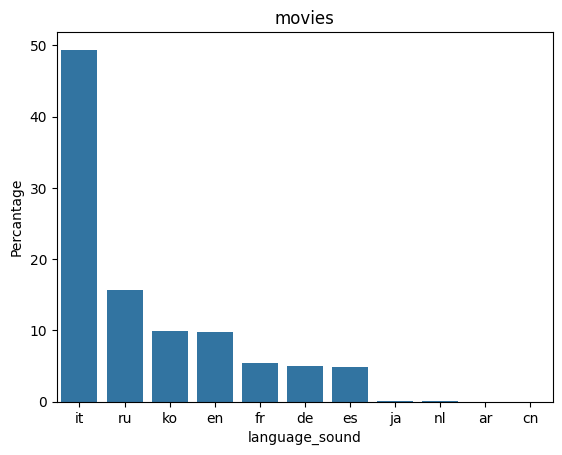

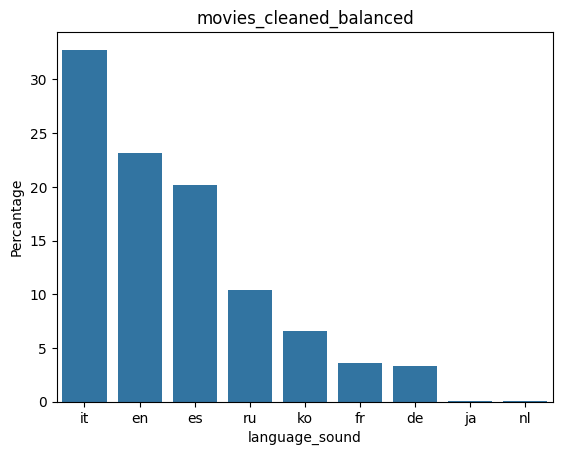

In [13]:
df_old = check_imbalances(movies_df, 'language_sound')
sns.barplot(x='group', y='percentage', data=df_old)
plt.xlabel('language_sound')
plt.ylabel('Percantage')
plt.title('movies')
plt.show()
    
df_new = check_imbalances(movies_clean_balanced_df, 'language_sound')
sns.barplot(x='group', y='percentage', data=df_new)
plt.xlabel('language_sound')
plt.ylabel('Percantage')
plt.title('movies_cleaned_balanced')
plt.show()

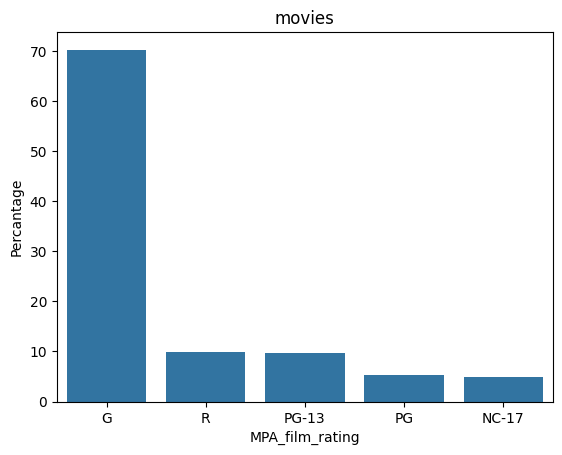

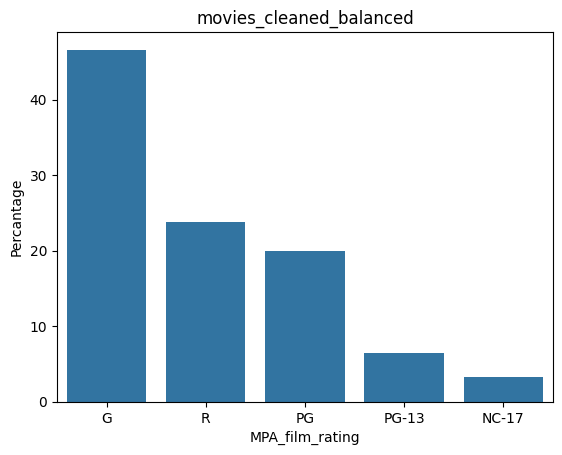

In [14]:
df_old = check_imbalances(movies_df, 'MPA_film_rating')
sns.barplot(x='group', y='percentage', data=df_old)
plt.xlabel('MPA_film_rating')
plt.ylabel('Percantage')
plt.title('movies')
plt.show()
    
df_new = check_imbalances(movies_clean_balanced_df, 'MPA_film_rating')
sns.barplot(x='group', y='percentage', data=df_new)
plt.xlabel('MPA_film_rating')
plt.ylabel('Percantage')
plt.title('movies_cleaned_balanced')
plt.show()

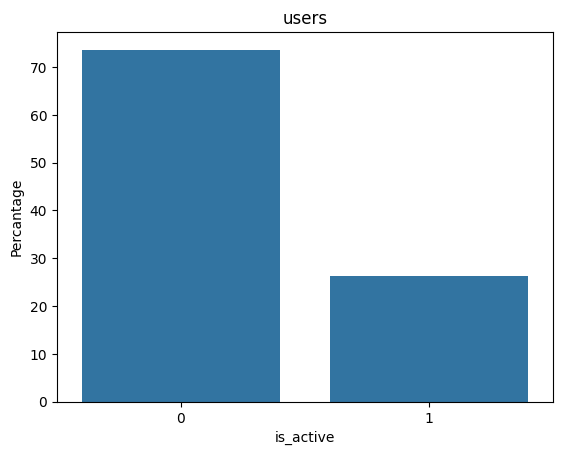

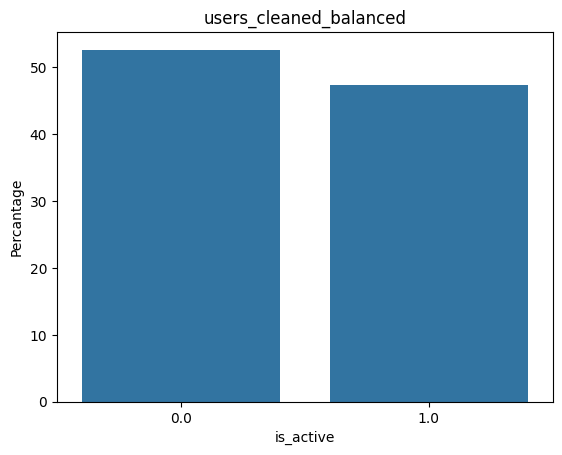

In [16]:
df_old = check_imbalances(users_df, 'is_active')
sns.barplot(x='group', y='percentage', data=df_old)
plt.xlabel('is_active')
plt.ylabel('Percantage')
plt.title('users')
plt.show()
    
df_new = check_imbalances(users_clean_balanced_df, 'is_active')
sns.barplot(x='group', y='percentage', data=df_new)
plt.xlabel('is_active')
plt.ylabel('Percantage')
plt.title('users_cleaned_balanced')
plt.show()

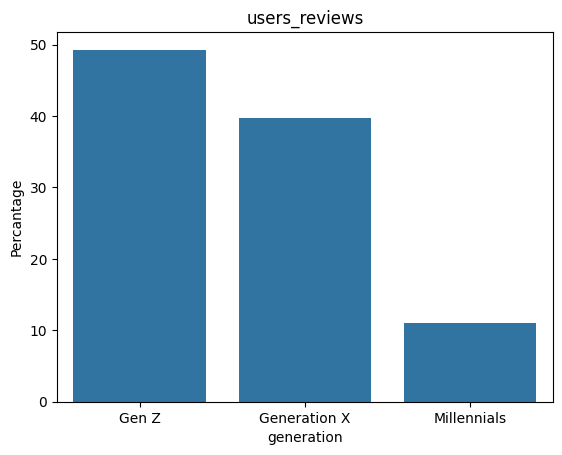

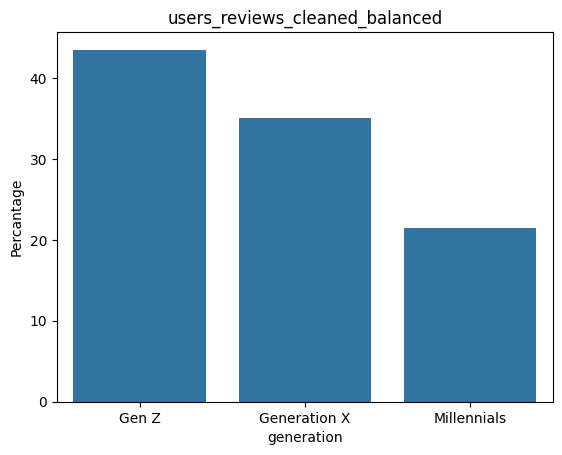

In [17]:
df_old = check_imbalances(users_reviews_extended_with_group_df, 'generation')
sns.barplot(x='group', y='percentage', data=df_old)
plt.xlabel('generation')
plt.ylabel('Percantage')
plt.title('users_reviews')
plt.show()
    
df_new = check_imbalances(users_reviews_extended_with_group_cb_df, 'generation')
sns.barplot(x='group', y='percentage', data=df_new)
plt.xlabel('generation')
plt.ylabel('Percantage')
plt.title('users_reviews_cleaned_balanced')
plt.show()

In [13]:
# original dataframes
movies_df
users_df
users_reviews_df

# cleansed dataframes
movies_clean_balanced_df
users_clean_balanced_df
users_reviews_clean_balanced_df

,review_id,user_id,movie_id,review_text,rating,review_date,rate
0,1,875,7115,What a incredible film! I really enjoyed this ...,4.3,2022-08-15,4-5 - Very Good
1,2,572,8887,It’s an average movie. I didn’t feel strongly ...,3.9,2024-10-28,4 - Good
2,3,364,2750,"This movie was alright, decent for a casual wa...",4.0,2023-06-28,4-5 - Very Good
3,4,1151,7304,"I regret watching this. The plot was terrible,...",2.2,2022-01-12,3 - An Average
4,5,928,2076,"The movie was average. Nothing special, but it...",3.7,2023-01-18,4 - Good
...,...,...,...,...,...,...,...
16980,16996,6996,12327,This movie is an average,3.2,1976-08-15,4 - Good
16981,16997,6997,11059,This movie is waste of time. I don't recommend it,1.5,2007-09-11,2 - Bad
16982,16998,6998,11214,This movie is could be better,2.4,2025-02-12,3 - An Average
16983,16999,6999,10178,This movie is acceptable,3.0,1974-11-29,4 - Good


# Analyze AI Summaries
## build a list of positive, neutral and negative words
Example:

In [34]:
stop_words = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 'yourself', 'yourselves',
    'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their',
    'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an',
    'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about',
    'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up',
    'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when',
    'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no',
    'nor', 'only', 'own', 'same', 'so', 'than', 'too', "can't", 'will', 'just', "don't", 'should', 'now',
    'film', 'movie', 'plot', 'cast', 'whole'
])

positive_words, negative_words, neutral_words = extract_adjectives_verbs_by_rating(users_reviews_clean_balanced_df, 'review_text', 'rating', 
                                                                                   'english-adjectives.txt', 'en-verbs.txt', stop_words)

print(positive_words)
print(negative_words)
print(neutral_words)


['mind', 'stood', 'say', 'make', 'get', 'blowing', 'true', 'might', 'experience', 'great', 'good', 'fine', 'feel', 'light', 'felt', 'can', 'romance', 'journey', 'end', 'watching', 'decent', 'see', 'wonderful', 'complete', 'enjoyed', 'enjoy', 'credits', 'hooked', 'miss', 'every', 'impressed', 'viewing', 'impress', 'hate', 'thought', 'seen', 'worth', 'second', 'call', 'fantastic', 'finish', 'time', 'better', 'superb', 'could', 'best', 'excellent', 'outstanding', 'haven', 'repeat', 'okay', 'bad', 'perfect', 'beginning', 'incredible', 'glad', 'don', 'brilliant', 'recommend', 'must', 'captivated', 'loved', 'keep', 'sold', 'write', 'looking', 'home', 'amazing', 'would', 'watch', 'watched', 'terrible', 'start', 'till', 'love']
['say', 'get', 'experience', 'great', 'good', 'fine', 'felt', 'acceptable', 'watching', 'real', 'frustrated', 'decent', 'see', 'couples', 'turned', 'boring', 'terrible', 'enjoy', 'total', 'found', 'viewing', 'thought', 'worth', 'slow', 'waste', 'time', 'better', 'could'

## count how many positive, neutral and negative words there are for each movie

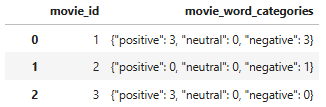

In [35]:
users_reviews_sentiment_df = add_sentiment_counts_column(users_reviews_clean_balanced_df, 'review_text', positive_words, negative_words, neutral_words, 'movie_word_categories')
users_reviews_sentiment_df

,review_id,user_id,movie_id,review_text,rating,review_date,rate,movie_word_categories
0,1,875,7115,What a incredible film! I really enjoyed this ...,4.3,2022-08-15,4-5 - Very Good,"{'positive': 4, 'negative': 2, 'neutral': 2}"
1,2,572,8887,It’s an average movie. I didn’t feel strongly ...,3.9,2024-10-28,4 - Good,"{'positive': 2, 'negative': 2, 'neutral': 3}"
2,3,364,2750,"This movie was alright, decent for a casual wa...",4.0,2023-06-28,4-5 - Very Good,"{'positive': 2, 'negative': 1, 'neutral': 2}"
3,4,1151,7304,"I regret watching this. The plot was terrible,...",2.2,2022-01-12,3 - An Average,"{'positive': 3, 'negative': 5, 'neutral': 3}"
4,5,928,2076,"The movie was average. Nothing special, but it...",3.7,2023-01-18,4 - Good,"{'positive': 0, 'negative': 1, 'neutral': 1}"
...,...,...,...,...,...,...,...,...
16980,16996,6996,14139,This movie is acceptable,2.8,1999-11-09,3 - An Average,"{'positive': 0, 'negative': 1, 'neutral': 1}"
16981,16997,6997,13144,This movie is outstanding. I reccomend it,4.6,1958-08-20,4-5 - Very Good,"{'positive': 1, 'negative': 0, 'neutral': 0}"
16982,16998,6998,11767,This movie is waste of time. I don't recommend it,1.4,1988-02-20,2 - Bad,"{'positive': 3, 'negative': 4, 'neutral': 1}"
16983,16999,6999,13325,This movie is terrible. I don't recommend it,0.2,2003-10-25,1 - Very bad,"{'positive': 3, 'negative': 3, 'neutral': 1}"


## identify dominant category (category with the highest count) according to following rules and set sentiment as expected sentiment column:

**Positive is Dominant**
If the number of positive words is greater apply formula for sentiment: 

neutral - 1 + negative < positive, classify as Positive, otherwise, classify as Neutral

**Neutral is Dominant**
If the number of neutral words is greater classify as Neutral

**Negative is Dominant**
If the number of negative words is greater apply formula for sentiment: 

positive + neutral ≥ negative, classify as Neutral, otherwise, classify as Negative

**No Dominant Category** 
If there is no single category with the highest count classify the sentiment as Neutral

**Example**: 
For movie_id = 1, we have: 
Positive words: 3
Neutral words: 0
Negative words: 3

Since Positive and Negative have the same count and neither is greater than the others → There is no dominant category. 
According to the rules, if there is no dominant category, the sentiment is classified as **Neutral**.

as result we expect the following: 

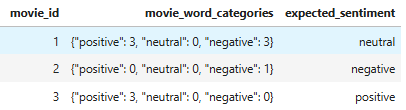

In [36]:
users_reviews_expected_sentiment_df = add_expected_sentiment(users_reviews_sentiment_df)
users_reviews_expected_sentiment_df['summary_id'] = users_reviews_expected_sentiment_df['movie_id']
users_reviews_expected_sentiment_df.sort_values(by=['movie_id'])

,review_id,user_id,movie_id,review_text,rating,review_date,rate,movie_word_categories,expected_sentiment,summary_id
265,267,184,1,It felt like a predictable experience. The mov...,0.9,2024-04-18,1 - Very bad,"{'positive': 2, 'negative': 5, 'neutral': 2}",negative,1
9319,9329,1481,1,This film was must-see from beginning to end. ...,4.6,2024-08-07,4-5 - Very Good,"{'positive': 5, 'negative': 3, 'neutral': 3}",neutral,1
10994,11007,1371,2,A terrible film that I regret watching. It was...,2.4,2023-08-20,3 - An Average,"{'positive': 2, 'negative': 4, 'neutral': 2}",neutral,2
998,1001,1015,2,"The film was average, not particularly great, ...",3.3,2023-09-13,4 - Good,"{'positive': 2, 'negative': 2, 'neutral': 3}",neutral,2
4170,11690,1099,3,I can't say enough about how loved this movie ...,4.7,2023-08-25,4-5 - Very Good,"{'positive': 5, 'negative': 2, 'neutral': 1}",positive,3
...,...,...,...,...,...,...,...,...,...,...
15752,15768,5768,14825,This movie is acceptable,2.5,2001-09-12,3 - An Average,"{'positive': 0, 'negative': 1, 'neutral': 1}",neutral,14825
16083,16099,6099,14825,This movie is poor. I don't recommend it,0.7,2001-09-12,1 - Very bad,"{'positive': 2, 'negative': 3, 'neutral': 0}",negative,14825
15876,15892,5892,14832,This movie is okay,3.8,1960-01-02,4 - Good,"{'positive': 1, 'negative': 1, 'neutral': 1}",neutral,14832
15769,15785,5785,14835,This movie is an average,2.9,2019-11-24,3 - An Average,"{'positive': 0, 'negative': 1, 'neutral': 1}",neutral,14835


## Compare calculated expected sentiment with AI sentiment

**Example**

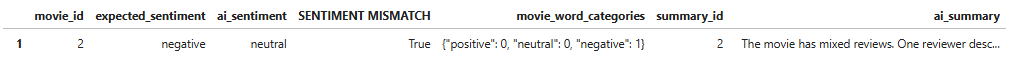

### Review the mismatches 

between the expected_sentiment (calculated based on user reviews) and the ai_sentiment (generated by the AI summary bot).

Then, reflect on why these mismatches may occur and share 3 possible reasons

In [37]:
users_reviews_actual_sentiment_df = pd.read_json('sentiment_ai.json')
users_reviews_actual_sentiment_df

,summary_id,movie_id,ai_summary,ai_sentiment
0,1,1,The movie is divisive. Opinions are divided. O...,neutral
1,2,2,The movie has mixed reviews. One reviewer desc...,neutral
2,3,3,The movie has mixed reviews. One reviewer foun...,neutral
3,4,4,The movie received high praise. Reviewers emph...,positive
4,5,5,The movie received mostly average reviews. One...,neutral
...,...,...,...,...
68,85,85,The movie received mixed feedback. One reviewe...,neutral
69,86,86,The movie was described as amazing and highly ...,positive
70,87,87,"The movie received negative feedback, with the...",negative
71,89,89,The movie was found to be good enough for a on...,neutral


In [38]:
users_reviews_actual_expected_df = pd.merge(users_reviews_actual_sentiment_df, users_reviews_expected_sentiment_df, on=['summary_id', 'movie_id'], how="inner")
users_reviews_actual_expected_df

,summary_id,movie_id,ai_summary,ai_sentiment,review_id,user_id,review_text,rating,review_date,rate,movie_word_categories,expected_sentiment
0,1,1,The movie is divisive. Opinions are divided. O...,neutral,267,184,It felt like a predictable experience. The mov...,0.9,2024-04-18,1 - Very bad,"{'positive': 2, 'negative': 5, 'neutral': 2}",negative
1,1,1,The movie is divisive. Opinions are divided. O...,neutral,9329,1481,This film was must-see from beginning to end. ...,4.6,2024-08-07,4-5 - Very Good,"{'positive': 5, 'negative': 3, 'neutral': 3}",neutral
2,2,2,The movie has mixed reviews. One reviewer desc...,neutral,1001,1015,"The film was average, not particularly great, ...",3.3,2023-09-13,4 - Good,"{'positive': 2, 'negative': 2, 'neutral': 3}",neutral
3,2,2,The movie has mixed reviews. One reviewer desc...,neutral,11007,1371,A terrible film that I regret watching. It was...,2.4,2023-08-20,3 - An Average,"{'positive': 2, 'negative': 4, 'neutral': 2}",neutral
4,3,3,The movie has mixed reviews. One reviewer foun...,neutral,4178,815,"It’s alright, watchable but not worth a repeat...",3.1,2022-07-10,4 - Good,"{'positive': 3, 'negative': 3, 'neutral': 3}",neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
140,85,85,The movie received mixed feedback. One reviewe...,neutral,5879,144,"The movie was terrible, a real letdown for me.",1.2,2022-09-02,2 - Bad,"{'positive': 1, 'negative': 2, 'neutral': 1}",neutral
141,86,86,The movie was described as amazing and highly ...,positive,8983,523,"Simply amazing. If you enjoy action, romance, ...",4.1,2023-04-30,4-5 - Very Good,"{'positive': 5, 'negative': 2, 'neutral': 3}",positive
142,87,87,"The movie received negative feedback, with the...",negative,5287,790,This movie was a real disappointment. I wouldn...,2.6,2022-11-24,3 - An Average,"{'positive': 1, 'negative': 2, 'neutral': 0}",negative
143,89,89,The movie was found to be good enough for a on...,neutral,5369,1654,This was a alright enough movie. I wouldn’t mi...,3.3,2023-08-03,4 - Good,"{'positive': 3, 'negative': 1, 'neutral': 3}",neutral


In [39]:
print(len(users_reviews_actual_expected_df[users_reviews_actual_expected_df['ai_sentiment'] != users_reviews_actual_expected_df['expected_sentiment']]))

56


In [40]:
users_reviews_actual_expected_df[users_reviews_actual_expected_df['ai_sentiment'] != users_reviews_actual_expected_df['expected_sentiment']]

,summary_id,movie_id,ai_summary,ai_sentiment,review_id,user_id,review_text,rating,review_date,rate,movie_word_categories,expected_sentiment
0,1,1,The movie is divisive. Opinions are divided. O...,neutral,267,184,It felt like a predictable experience. The mov...,0.9,2024-04-18,1 - Very bad,"{'positive': 2, 'negative': 5, 'neutral': 2}",negative
5,3,3,The movie has mixed reviews. One reviewer foun...,neutral,11690,1099,I can't say enough about how loved this movie ...,4.7,2023-08-25,4-5 - Very Good,"{'positive': 5, 'negative': 2, 'neutral': 1}",positive
9,5,5,The movie received mostly average reviews. One...,neutral,7240,1252,"I couldn’t get into the movie. It was boring, ...",2.0,2023-01-28,3 - An Average,"{'positive': 1, 'negative': 4, 'neutral': 0}",negative
11,6,6,"The movie received a good review, with finding...",positive,3887,1255,"The movie was alright, it did not impress me, ...",3.5,2023-12-15,4 - Good,"{'positive': 2, 'negative': 1, 'neutral': 2}",neutral
14,8,8,"The movie has received a positive reception, w...",positive,4645,1466,This movie is great to waste time! Suggest it ...,0.5,2022-06-18,1 - Very bad,"{'positive': 2, 'negative': 6, 'neutral': 2}",negative
18,11,11,"The movie was highly recommended, with describ...",positive,11831,545,"A highly recommend movie that’s so good, I wou...",4.2,2022-07-26,4-5 - Very Good,"{'positive': 4, 'negative': 4, 'neutral': 2}",neutral
19,12,12,"The movie is highly praised, with viewers call...",positive,1639,812,This movie is incredible. I had an amazing tim...,4.9,2024-11-17,4-5 - Very Good,"{'positive': 4, 'negative': 2, 'neutral': 3}",neutral
21,12,12,"The movie is highly praised, with viewers call...",positive,14454,1325,I would say this movie was poor. A total waste...,1.3,2023-10-04,2 - Bad,"{'positive': 3, 'negative': 6, 'neutral': 3}",neutral
29,17,17,The movie received a mix of opinions. Some fou...,neutral,4892,1420,A highly recommend journey from start to credi...,4.3,2022-08-11,4-5 - Very Good,"{'positive': 6, 'negative': 3, 'neutral': 1}",positive
30,18,18,The movie was praised as an unforgettable and ...,positive,2702,333,I had such an amazing experience with this fil...,4.3,2024-01-26,4-5 - Very Good,"{'positive': 2, 'negative': 1, 'neutral': 2}",neutral


# Mismatch reasons:
#### 1) AI generated sentiment doesn't count 'user_id' column, which results doubled dataset. The same movie might have reviews from 
multiple users which isn't taken into account in 'sentiment_ai.json'
#### 2) If two or more categories have the same highest count, sentiment will be 'neutral' (case 4). This is by design, but worth to handle ties differently.
#### 3-4) The formulas for determining sentiment in the dominant cases are somewhat arbitrary and may not always align with human intuition. For example:
    - For positive dominance: neutral - 1 + negative < positive
    - For negative dominance: positive + neutral >= negative

In [21]:
users_reviews_df.sort_values(by='movie_id')

,review_id,user_id,movie_id,review_text,rating,review_date,rate
9325,9329,1481,1,This film was must-see from beginning to end. ...,4.6,8/7/2024,4-5 - Very Good
265,267,184,1,It felt like a predictable experience. The mov...,0.9,4/18/2024,1 - Very bad
998,1001,1015,2,"The film was average, not particularly great, ...",3.3,9/13/2023,4 - Good
11003,11007,1371,2,A terrible film that I regret watching. It was...,2.4,8/20/2023,3 - An Average
236,4178,815,3,"It’s alright, watchable but not worth a repeat...",3.1,7/10/2022,4 - Good
...,...,...,...,...,...,...,...
3678,3681,1337,8997,I had such an wonderful experience with this f...,4.2,6/13/2024,4-5 - Very Good
4551,4554,506,8998,It was a okay movie. I wouldn’t say it was ama...,3.4,11/16/2023,4 - Good
4959,4962,844,8998,I had such an highly recommend experience with...,4.1,4/26/2024,4-5 - Very Good
5348,5351,213,8999,This is an alright movie that might be worth w...,3.2,11/8/2022,4 - Good
